In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# The Fokker--Planck Equation and Probability Flow

A single path of a stochastic differential equation is jagged, unrepeatable,
and, as that section showed, nowhere differentiable. Run the
simulation again and you get a different curve. But now release a *cloud*: a
million points drawn from a density $p_0$, every one of them flowing under the
same SDE. Each particle is unpredictable, yet the cloud's density
$p_t(\mathbf{x})$ evolves in a perfectly deterministic, perfectly reproducible
way: drift pushes it, diffusion smears it. This switch of viewpoint, from
one trajectory to the evolving ensemble, is the move diffusion models are
built on, and the law of motion of the cloud is a partial differential
equation: the **Fokker--Planck equation**.

From that one PDE follow two facts that diffusion models rest on. First, every
noising SDE has a *deterministic twin*, the **probability-flow ODE**, whose
smooth trajectories pass through exactly the same time-marginals $p_t$ as the
SDE's jagged paths [@song2021score]. Second, running the noising process
*backward*, turning noise into data, is again an SDE, and its drift involves
exactly one quantity we do not already know: the **score**
$\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ [@Anderson.1982]. Everything
else (the drift $\mathbf{f}$, the noise schedule $g$) we chose ourselves when
we designed the forward process. The slogan of this chapter, *we just need the
score*, is proved here; that section then
learns it from data.

The route: we first make the path-vs.-cloud picture precise and assemble the
three vector-calculus identities the section runs on (divergence, Laplacian,
integration by parts in $d$ dimensions). We then derive the
Fokker--Planck equation from Itô's lemma, check it in closed form and
numerically on the Ornstein--Uhlenbeck process, rewrite it as a *continuity
equation* via a one-line identity, and read off the probability-flow ODE. The
score function gets its own treatment (worked Gaussians and mixtures, and
the normalizer-invariance that makes it learnable) before Anderson's
time-reversal theorem turns the forward process around. Throughout, the code
verifies every claim with plain NumPy: no learning, no deep-learning library,
every density in closed form.

In [1]:
%matplotlib inline
from d2l import tensorflow as d2l
import numpy as np

## From Paths to Densities

### One Trajectory or the Whole Cloud

Fix an SDE in the form we will use throughout,

$$
d\mathbf{X} = \mathbf{f}(\mathbf{X}, t)\,dt + g(t)\,d\mathbf{W},
$$

with drift $\mathbf{f} : \mathbb{R}^d \times [0, T] \to \mathbb{R}^d$ and a
scalar noise schedule $g(t)$, and start it from a random initial condition
$\mathbf{X}_0 \sim p_0$. There are two ways to watch what happens next.

The *Lagrangian* view follows one particle: a single realization of the
Brownian motion produces a single path $\mathbf{X}_t(\omega)$, different on
every run. The *Eulerian* view stands still at a point $\mathbf{x}$ and watches
the crowd stream past: it tracks the **time-marginal**
$p_t(\mathbf{x})$, the density of the random variable $\mathbf{X}_t$. The
marginal averages over both sources of randomness (the draw of
$\mathbf{X}_0$ and the noise along the way), and that averaging is exactly
what makes it deterministic. Run the experiment twice with a large cloud and
you get two indistinguishable evolving densities, even though no two
individual paths agree.

Our running example is the Ornstein--Uhlenbeck (OU) process of
that section, $dX = -\theta X\,dt + \sigma\,dW$, whose
marginals we know in closed form: started from a point $X_0 = x_0$,

$$
X_t \sim \mathcal{N}\!\left(x_0 e^{-\theta t},\; \frac{\sigma^2}{2\theta}\left(1 - e^{-2\theta t}\right)\right),
$$

the transition kernel the equation, restated here for
repeated use: a Gaussian whose mean decays toward the origin and whose
variance saturates at the stationary value $\sigma^2 / 2\theta$ derived in
that section. Qualitatively, the drift
*transports* probability mass (the cloud's center of mass slides along the
deterministic flow $\dot{x} = -\theta x$), while the diffusion *spreads and
smooths* it (the cloud widens the way heat spreads along a metal bar). The
Fokker--Planck equation will make both halves of that sentence into operators.

### Three Identities from Vector Calculus

The rest of this section speaks the language of vector calculus. Beyond the
gradient of that section, we need exactly three
facts about a smooth vector field
$\mathbf{v} : \mathbb{R}^d \to \mathbb{R}^d$ and a smooth scalar field
$h : \mathbb{R}^d \to \mathbb{R}$. None of them is hard, and together they
are the entire toolkit.

**Divergence.** The divergence of $\mathbf{v}$ is the scalar field

$$
\nabla \cdot \mathbf{v} = \sum_{i=1}^d \frac{\partial v_i}{\partial x_i}.
$$

Its meaning is *flux per unit volume*: if $\mathbf{v}$ is the velocity of a
fluid, then $\nabla \cdot \mathbf{v}(\mathbf{x})$ is the net rate at which
fluid exits an infinitesimal box around $\mathbf{x}$, divided by the box's
volume: positive at a source, negative at a sink, zero for an
incompressible flow. The local statement integrates up to the **divergence
theorem**: for a bounded region $\Omega$ with outward unit normal $\mathbf{n}$,

$$
\int_\Omega \nabla \cdot \mathbf{v}\; d\mathbf{x} = \oint_{\partial\Omega} \mathbf{v} \cdot \mathbf{n}\; dS,
$$

i.e., the total "sourceness" inside a region equals the net flux out through
its boundary. In one dimension this is just the fundamental theorem of
calculus, $\int_a^b v'(x)\,dx = v(b) - v(a)$: what accumulates inside $[a, b]$
is whatever crosses the two endpoints. We take the divergence theorem itself
as a granted fact; a proof is in @Folland.1999 .

**Laplacian.** The Laplacian is the divergence of the gradient,

$$
\Delta h = \nabla \cdot (\nabla h) = \sum_{i=1}^d \frac{\partial^2 h}{\partial x_i^2}.
$$

It measures how $h$ at a point compares with its neighborhood: averaging $h$
over a small sphere of radius $r$ centered at $\mathbf{x}$ gives
$h(\mathbf{x}) + \frac{r^2}{2d}\Delta h(\mathbf{x}) + O(r^4)$. So
$\Delta h > 0$ means "below the neighborhood average." That is why the heat
equation $\partial_t u = \Delta u$ smooths: it raises $u$ exactly where $u$
sits below the average of its neighbors, and lowers it where it sits above.

**Integration by parts.** This is the $d$-dimensional form of the
one-dimensional rule of that section. If $h$ and
$\mathbf{v}$ are smooth and decay fast enough at infinity (for us: $h$ a
compactly supported test function, or Gaussian-tailed densities), then

$$
\int h\, (\nabla \cdot \mathbf{v})\; d\mathbf{x} = -\int \nabla h \cdot \mathbf{v}\; d\mathbf{x}.
$$

*Proof in one line:* the product rule gives
$\nabla \cdot (h \mathbf{v}) = \nabla h \cdot \mathbf{v} + h\, \nabla \cdot \mathbf{v}$;
integrate both sides over a ball of radius $R$ and let $R \to \infty$: by
the divergence theorem the left side is a boundary flux of $h\mathbf{v}$,
which the decay kills. $\blacksquare$

Applied twice with $\mathbf{v} = \nabla u$, integration by parts moves a whole
Laplacian across the integral sign: $\int h\, \Delta u = \int u\, \Delta h$.
That maneuver, shifting derivatives from a test function onto a density,
is the only trick the Fokker--Planck derivation needs.

### Watching the Cloud

Before deriving anything, let us *see* the claim that the marginal is
deterministic and, for OU, exactly the Gaussian
the equation. We release $100{,}000$ particles from the
point $x_0 = 2$, march them with Euler--Maruyama
(that section), and compare histograms of the cloud
against the analytic density at three times. We take $\theta = 1$ and
$\sigma = \sqrt{2}$ throughout, so the stationary law is exactly
$\mathcal{N}(0, 1)$.

t=0.1: cloud mean +1.8121 (analytic +1.8097), std 0.4275 (analytic 0.4258)
t=0.5: cloud mean +1.2137 (analytic +1.2131), std 0.7987 (analytic 0.7951)
t=2.0: cloud mean +0.2750 (analytic +0.2707), std 0.9889 (analytic 0.9908)


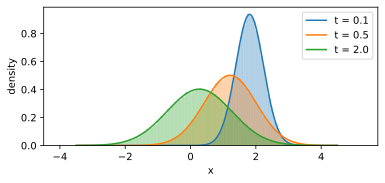

In [2]:
theta, sigma = 1.0, np.sqrt(2.0)        # OU: dX = -theta X dt + sigma dW

def ou_mean_var(x0, t):                 # closed-form marginal N(m_t, v_t)
    m = x0 * np.exp(-theta * t)
    v = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * t))
    return m, v

rng = np.random.default_rng(42)
n, dt, T = 100_000, 0.002, 2.0
cloud = np.full(n, 2.0)                 # every particle starts at x0 = 2
ts_show, snaps = (0.1, 0.5, 2.0), {}
for k in range(int(round(T / dt))):
    cloud += -theta * cloud * dt + sigma * np.sqrt(dt) * rng.standard_normal(n)
    t = (k + 1) * dt
    if any(abs(t - s) < 1e-9 for s in ts_show):
        snaps[round(t, 3)] = cloud.copy()

grid = np.linspace(-3.5, 4.5, 400)
d2l.set_figsize((6, 2.5))
for t, color in zip(ts_show, ('C0', 'C1', 'C2')):
    m, v = ou_mean_var(2.0, t)
    d2l.plt.hist(snaps[t], bins=80, density=True, alpha=0.35, color=color)
    d2l.plt.plot(grid, np.exp(-(grid - m)**2 / (2 * v)) / np.sqrt(2 * np.pi * v),
                 color=color, label=f't = {t}')
    print(f't={t}: cloud mean {snaps[t].mean():+.4f} (analytic {m:+.4f}), '
          f'std {snaps[t].std():.4f} (analytic {np.sqrt(v):.4f})')
d2l.plt.xlabel('x'); d2l.plt.ylabel('density'); d2l.plt.legend();

The histograms sit on their analytic curves: at $t = 0.5$ the cloud's mean
$1.2137$ and standard deviation $0.7987$ match the analytic
$2e^{-0.5} \approx 1.2131$ and $\sqrt{1 - e^{-1}} \approx 0.7951$ to within a
few parts in a thousand (the gap is Euler--Maruyama discretization plus
sampling noise), and by $t = 2$ the cloud is already close to the stationary
$\mathcal{N}(0, 1)$.
One hundred thousand random walks, one deterministic density movie. The next
subsection writes down the PDE that this movie obeys.

## The Fokker--Planck Equation

### From Itô's Lemma to a PDE

Here is the derivation, intuition first. We cannot differentiate a path, but
we *can* differentiate the expectation of a smooth function along a path:
Itô's lemma (that section) tells us how. Probing the density
with every smooth function then pins the density down completely.

Take any smooth, compactly supported **test function**
$\phi : \mathbb{R}^d \to \mathbb{R}$. For
$d\mathbf{X} = \mathbf{f}\,dt + g\,d\mathbf{W}$, the multivariate Itô
lemma the equation with $G = g(t)\, I$ reads

$$
d\phi(\mathbf{X}) = \left(\nabla\phi \cdot \mathbf{f} + \tfrac12 g^2 \Delta\phi\right) dt + g\, \nabla\phi \cdot d\mathbf{W} :
$$

the ordinary chain rule plus the second-order Taylor term that
$(dW)^2 = dt$ promotes to first order; with scalar $g$, that correction
$\tfrac12 \sum_{ij} (G G^\top)_{ij}\, \partial^2_{x_i x_j}\phi$ collapses to
exactly $\tfrac12 g^2$ times the Laplacian of $\phi$. Now take expectations.
The Itô integral has zero mean (that section), so the noise
term vanishes and

$$
\frac{d}{dt}\, \mathbb{E}[\phi(\mathbf{X}_t)] = \mathbb{E}\!\left[\nabla\phi \cdot \mathbf{f} + \tfrac12 g^2 \Delta\phi\right].
$$

Both sides are integrals against the marginal density: writing
$\mathbb{E}[\,\cdot\,] = \int (\cdot)\, p_t(\mathbf{x})\, d\mathbf{x}$,

$$
\int \phi\; \partial_t p_t\; d\mathbf{x} = \int (\nabla\phi \cdot \mathbf{f})\, p_t\; d\mathbf{x} + \tfrac12 g^2 \int (\Delta\phi)\, p_t\; d\mathbf{x}.
$$

The derivatives sit on $\phi$, where we cannot use them; integration by parts
the equation moves them onto $p_t$, where we can.
Applied once to the drift term (with $h = \phi$,
$\mathbf{v} = \mathbf{f} p_t$) and twice to the diffusion term,

$$
\int \phi\, \partial_t p_t\; d\mathbf{x} = \int \phi \left[-\nabla \cdot (\mathbf{f}\, p_t) + \tfrac12 g^2 \Delta p_t\right] d\mathbf{x}.
$$

This holds for *every* test function $\phi$. Here we fix the standing
assumptions of the whole section: $p_t$ is smooth and strictly positive,
differentiation under the integral sign is justified, and $p_t$ decays fast
enough at infinity that the products $\mathbf{f}\, p_t$ and $\nabla p_t$
vanish there. (The decay must cover the *products*: the OU drift grows
linearly, so it is $\mathbf{f}\, p_t$, not $p_t$ alone, that has to vanish;
Gaussian tails oblige.) Under these assumptions both integrands are
continuous, and a continuous function that integrates to zero against every
test function is identically zero, so the integrands agree pointwise and
$p_t$ solves the resulting PDE classically. That PDE is the **Fokker--Planck
equation** [@Fokker.1914; @Planck.1917] (also the *Kolmogorov forward
equation* [@Kolmogorov.1931]; physicists' conventions and many
generalizations are in @Risken.1996):

$$
\partial_t p_t(\mathbf{x}) = -\nabla \cdot \big(\mathbf{f}(\mathbf{x}, t)\, p_t(\mathbf{x})\big) + \tfrac12 g(t)^2\, \Delta p_t(\mathbf{x}).
$$

For a full matrix diffusion $G(\mathbf{x}, t)\,d\mathbf{W}$, put
$a=GG^\top$. The second-order term is then
$\tfrac12 \sum_{ij} \partial_i\partial_j(a_{ij}p_t)$. The scalar-$g$
case used in most examples is the special choice $a=g(t)^2I$, for which this
reduces to $\tfrac12 g(t)^2\Delta p_t$.

### Diffusion Matrices and Boundary Conditions

The matrix formula becomes easier to interpret when written as conservation
of probability. Define the probability current componentwise by

$$
J_i(\mathbf{x},t)
= f_i(\mathbf{x},t)p_t(\mathbf{x})
- \frac12\sum_j \partial_j\big(a_{ij}(\mathbf{x},t)p_t(\mathbf{x})\big).
$$

Then the general Fokker--Planck equation is simply
$\partial_t p_t=-\nabla\cdot\mathbf{J}$. Integrating it over a domain
$\Omega$ gives

$$
\frac{d}{dt}\int_\Omega p_t(\mathbf{x})\,d\mathbf{x}
= -\int_{\partial\Omega}\mathbf{J}\cdot\mathbf{n}\,dS.
$$

This identity also says which boundary assumptions a derivation has hidden.
On all of $\mathbb{R}^d$ we require the current to decay sufficiently fast.
A **reflecting** boundary imposes $\mathbf{J}\cdot\mathbf{n}=0$; periodic
boundaries match density and flux on opposite faces. A common **absorbing**
condition is $p=0$ on the boundary, in which case probability may leave the
domain and the integral of $p$ need not remain one unless an absorbed state is
included. Integration by parts without the matching boundary term is not
valid in these settings.

Where $p_t>0$, dividing the current by the density gives the general
probability-flow velocity

$$
\mathbf{v}
= \frac{\mathbf{J}}{p_t}
= \mathbf{f}-\frac12\,a\nabla\log p_t
  -\frac12\,\nabla\cdot a,
\qquad
(\nabla\cdot a)_i=\sum_j\partial_j a_{ij}.
$$

Thus state-dependent or anisotropic noise contributes both a score term and a
spatial-divergence term. The later formula
$\mathbf{f}-\tfrac12g^2\nabla\log p_t$ is precisely the simplification for
$a=g(t)^2I$.

### Drift Transports, Diffusion Smooths

Read the equation term by term. The first term,
$-\nabla \cdot (\mathbf{f} p)$, is *advection*: probability streams along the
drift field exactly like dye carried by a current; we will see in the next
section that it is the signature of pure transport. The second term,
$\tfrac12 g^2 \Delta p$, is *diffusion*: by the neighborhood-average reading
of the Laplacian, it raises the density wherever the density dips below its
surroundings, smoothing peaks away. It is the
$(dW)^2 = dt$ correction of Itô's lemma made macroscopic.

Switch the drift off entirely and the Fokker--Planck equation *is* the **heat
equation**,

$$
\mathbf{f} = \mathbf{0} : \qquad \partial_t p_t = \tfrac12 g^2\, \Delta p_t,
$$

whose Gaussian solutions spread with linearly growing variance
$v(t) = v_0 + g^2 t$, precisely the $\mathrm{Var}(W_t) = t$ law of Brownian
motion from that section (with $g \equiv 1$). Diffusion models'
"variance-exploding" forward process (that section) is exactly this
equation with a time-dependent $g$.

### The Ornstein--Uhlenbeck Check

For OU in one dimension,
$f(x) = -\theta x$ and $g = \sigma$, equation the equation
reads

$$
\partial_t p = \theta\, \partial_x (x\, p) + \tfrac12 \sigma^2\, \partial_{xx} p,
$$

and we claim the Gaussian marginal the equation solves it.
To see this, and to see *which* Gaussians solve it, plug in a generic
Gaussian and watch the PDE collapse into two ODEs for the mean and variance.

**Proposition (Gaussian solutions of the OU equation).** *Let
$p(x, t) = \mathcal{N}(x; m(t), v(t))$ be a Gaussian density with
differentiable mean $m(t)$ and variance $v(t) > 0$. Then $p$ solves the OU
Fokker--Planck equation if and only if*

$$
\dot{m} = -\theta m, \qquad \dot{v} = \sigma^2 - 2\theta v.
$$

**Proof.** For a Gaussian, $\partial_x p = -\frac{x - m}{v}\, p$. Direct
differentiation turns each side of the PDE into $p$ times a quadratic
polynomial in $(x - m)$:

$$
\partial_t p = p \left[\frac{\dot m}{v}(x - m) + \frac{\dot v}{2v^2}\big((x - m)^2 - v\big)\right],
$$

while, writing $x = (x - m) + m$ in the drift term,

$$
\theta\, \partial_x(x p) + \tfrac{\sigma^2}{2} \partial_{xx} p = p \left[-\frac{\theta m}{v}(x - m) + \Big(\frac{\sigma^2}{2v^2} - \frac{\theta}{v}\Big)\big((x - m)^2 - v\big)\right].
$$

The functions $1, (x - m), (x - m)^2$ are linearly independent, so the two
sides agree for all $x$ exactly when the coefficients match:
$\dot{m} = -\theta m$ from the linear term and
$\dot{v} = \sigma^2 - 2\theta v$ from the quadratic term (the constant term
repeats the latter). $\blacksquare$

The OU marginal the equation has
$m(t) = x_0 e^{-\theta t}$ and
$v(t) = \frac{\sigma^2}{2\theta}(1 - e^{-2\theta t})$, which satisfy
the equation on sight, so the transition density of
that section solves Fokker--Planck, by direct
differentiation. The fixed point $\dot m = \dot v = 0$ gives $m = 0$,
$v = \sigma^2/2\theta$: the stationary Gaussian is the *steady state*
$\partial_t p = 0$ of the PDE (you will re-derive it from scratch, without the
Gaussian ansatz, in the exercises). And setting $\theta = 0$ recovers the heat
equation's linear variance growth $\dot v = \sigma^2$.

Closed form is good; a numerical check is better, since it also exercises the
machinery we will trust later. We evaluate both sides of the PDE by finite
differences on a grid ($\partial_t$ by a centered difference in time,
$\partial_x$ and $\partial_{xx}$ by `np.gradient`) and measure the
residual.

In [3]:
def ou_density(x, t, x0=2.0):
    m, v = ou_mean_var(x0, t)
    return np.exp(-(x - m)**2 / (2 * v)) / np.sqrt(2 * np.pi * v)

xs = np.linspace(-4.0, 5.0, 4001)
dx = xs[1] - xs[0]
for t in ts_show:
    eps = 1e-5
    dpdt = (ou_density(xs, t + eps) - ou_density(xs, t - eps)) / (2 * eps)
    p = ou_density(xs, t)
    transport = np.gradient(theta * xs * p, dx)        # -d/dx(f p), f = -theta x
    diffusion = 0.5 * sigma**2 * np.gradient(np.gradient(p, dx), dx)
    residual = (dpdt - (transport + diffusion))[5:-5]  # trim one-sided edge stencils
    print(f't={t}: max|residual| = {np.abs(residual).max():.2e}, '
          f'max|dp/dt| = {np.abs(dpdt).max():.2e}')

t=0.1: max|residual| = 1.34e-04, max|dp/dt| = 4.82e+00
t=0.5: max|residual| = 4.56e-06, max|dp/dt| = 5.40e-01
t=2.0: max|residual| = 1.08e-06, max|dp/dt| = 6.70e-02


At every time the residual is four to five orders of magnitude below the scale
of $\partial_t p$ (at $t = 0.5$, a residual of $5 \times 10^{-6}$ against a
left-hand side of size $0.54$): pure finite-difference truncation error. The
cloud's evolving density really does obey the equation.

One further reading, for later context: for a gradient drift
$\mathbf{f} = -\nabla V$ and constant $g$, the Fokker--Planck equation is the
steepest-descent flow of a free-energy functional in the Wasserstein geometry
of optimal transport (that section), a result of
@Jordan.Kinderlehrer.Otto.1998 . We will not use this, but it is why
transport mathematics keeps resurfacing here, from the continuity equation
below to the Benamou--Brenier principle [@Benamou.Brenier.2000] that
that section builds on.

## The Continuity Equation and the Probability-Flow ODE

### Conservation of Probability

Forget noise for a moment. Suppose particles move *deterministically*, each
one following a velocity field: $\dot{\mathbf{x}} = \mathbf{v}(\mathbf{x}, t)$.
What PDE does their density $q_t$ obey? Probability mass is never created or
destroyed: the amount inside any fixed region $\Omega$ can change only by
mass *flowing across the boundary*. Particles cross a boundary patch at rate
(density) $\times$ (velocity), so the flux density is $q\mathbf{v}$, and

$$
\frac{d}{dt} \int_\Omega q_t\; d\mathbf{x} = -\oint_{\partial\Omega} q_t\, \mathbf{v} \cdot \mathbf{n}\; dS = -\int_\Omega \nabla \cdot (q_t \mathbf{v})\; d\mathbf{x},
$$

the divergence theorem the equation converting the
boundary flux into a volume integral. Since $\Omega$ is arbitrary, the
integrands agree pointwise. The result is the **continuity equation**:

$$
\partial_t q_t + \nabla \cdot (q_t\, \mathbf{v}) = 0.
$$

It is the same conservation law that governs fluids and electric charge. The
flux density $\mathbf{j} = q\, \mathbf{v}$ is called the **probability
current**: at each point it gives the rate, per unit area, at which
probability crosses a surface placed there. In one dimension the current
makes the bookkeeping vivid, $\partial_t \int_a^b q\,dx = j(a) - j(b)$: what
flows in at $a$ minus what leaks out at $b$.
the figure draws exactly this balance.

![The continuity equation as a flux balance. A density $p(x)$ (blue) is carried by a drift $f$, giving the probability current $j(x)=f\,p(x)$. Over the fixed region from $a$ to $b$ the enclosed mass (orange) changes only through the current crossing its two boundaries: $\partial_t\int_a^b p\,dx = j(a)-j(b)$, the net inward flux. Probability is conserved, never created or destroyed inside the region.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-fokker-planck-flux.svg)

Two consequences fall out immediately. Integrating
the equation over all of $\mathbb{R}^d$ kills the divergence
term (it is the flux of $q_t \mathbf{v}$ at infinity, which the decay of that
product kills), so total mass $\int q_t = 1$ is conserved automatically. And
along a trajectory of the flow, a particle's log-density changes at minus the
local divergence,

$$
\frac{d}{dt} \log q_t(\mathbf{x}(t)) = -\nabla \cdot \mathbf{v}(\mathbf{x}(t), t) :
$$

this is the instantaneous change-of-variables formula
the equation, proved in
that section; in the present language it is
just the continuity equation with its divergence expanded and read along
characteristics. We are about to make diffusion models eligible for it.

### Diffusion Is Transport in Disguise

The Fokker--Planck equation the equation is *not* in
continuity form: alongside the transport term $-\nabla \cdot (\mathbf{f} p)$
it carries the Laplacian, which looks like a different species. The key
observation, one line of calculus, is that it is not. Wherever
$p > 0$, the chain rule gives

$$
\nabla p = p\, \nabla \log p,
$$

and therefore

$$
\tfrac12 g^2\, \Delta p = \tfrac12 g^2\, \nabla \cdot (\nabla p) = \nabla \cdot \big(p \cdot \tfrac12 g^2 \nabla \log p\big).
$$

The standalone rewrite
the equation carries a *plus*: the diffusion
term equals the divergence of $p$ times $+\tfrac12 g^2 \nabla \log p$. The
familiar minus sign appears only at the next step, when we fold this term into
the continuity form $-\nabla \cdot (p\, \mathbf{v})$ and the velocity absorbs
it as $-\tfrac12 g^2 \nabla \log p$. (Putting the minus in both places is a
popular way to derive a contradiction.)

**Proposition (Fokker--Planck is a continuity equation).** *Wherever
$p_t > 0$, the Fokker--Planck equation the equation is
equivalent to*

$$
\partial_t p_t + \nabla \cdot (p_t\, \mathbf{v}_t) = 0, \qquad \mathbf{v}_t(\mathbf{x}) = \mathbf{f}(\mathbf{x}, t) - \tfrac12 g(t)^2\, \nabla \log p_t(\mathbf{x}).
$$

**Proof.** Substitute the equation into
the equation and merge the two divergences:

$$
\partial_t p = -\nabla \cdot (\mathbf{f} p) + \nabla \cdot \big(p \cdot \tfrac12 g^2 \nabla \log p\big) = -\nabla \cdot \big(p\, [\mathbf{f} - \tfrac12 g^2 \nabla \log p]\big). \qquad \blacksquare
$$

The diffusing cloud is therefore *indistinguishable, at the level of
densities*, from a crowd of particles drifting deterministically with the
effective velocity $\mathbf{v}_t$: the drift we designed, minus a correction
that pushes *down* the density gradient (away from crowded regions:
diffusion's smoothing, reproduced by pure transport). Because the
identity is the engine of everything that follows, we check it
numerically: both sides of
the equation on a grid, for the OU Gaussian, along
with the sign-flipped impostor.

In [4]:
p = ou_density(xs, 0.5)
lhs = 0.5 * sigma**2 * np.gradient(np.gradient(p, dx), dx)
score_fd = np.gradient(np.log(p), dx)
rhs = np.gradient(p * (0.5 * sigma**2 * score_fd), dx)      # correct: + sign
wrong = np.gradient(p * (-0.5 * sigma**2 * score_fd), dx)   # sign-flipped
trim = slice(5, -5)                                         # drop edge stencils
print(f'max|lhs| = {np.abs(lhs[trim]).max():.3e}')
print(f'max|lhs - rhs|   (plus sign)  = {np.abs((lhs - rhs)[trim]).max():.3e}')
print(f'max|lhs - wrong| (minus sign) = {np.abs((lhs - wrong)[trim]).max():.3e}')

max|lhs| = 7.938e-01
max|lhs - rhs|   (plus sign)  = 3.179e-06
max|lhs - wrong| (minus sign) = 1.588e+00


The correct identity holds to finite-difference precision (the two sides
agree to $3 \times 10^{-6}$ on terms of size $0.79$, five orders of
magnitude), while the sign-flipped version misses by $1.59$, twice the size
of the term itself, exactly as $-x$ misses $x$. Signs matter.

### The Probability-Flow ODE

A continuity equation is the law of motion of a *deterministic* flow. So the
proposition above hands us, for free, an ODE whose particles sweep out the
same evolving density as the SDE's random walkers:

$$
\frac{d\mathbf{x}}{dt} = \mathbf{v}_t(\mathbf{x}) = \mathbf{f}(\mathbf{x}, t) - \tfrac12 g(t)^2\, \nabla \log p_t(\mathbf{x}),
$$

the **probability-flow ODE** of @song2021score.

**Proposition (the deterministic twin).** *Let $p_t$ be the (smooth, positive,
decaying) solution of the Fokker--Planck equation for the SDE
$d\mathbf{X} = \mathbf{f}\,dt + g\,d\mathbf{W}$ with
$\mathbf{X}_0 \sim p_0$. Let $\mathbf{x}(t)$ solve the ODE
the equation with $\mathbf{x}(0) \sim p_0$. Then
$\mathbf{x}(t) \sim p_t$ for every $t$: the ODE and the SDE share all
time-marginals.*

**Proof.** Let $q_t$ be the density of the ODE's state. The field
$\mathbf{v}_t$ is a fixed, known velocity field (built from $p$, not from
$q$), so $q_t$ obeys the continuity equation
$\partial_t q = -\nabla \cdot (q \mathbf{v}_t)$, a *linear* transport PDE
in $q$. By the previous proposition, $p_t$ solves the same PDE, and both start
from the same initial density $q_0 = p_0$. A linear transport equation with a
smooth velocity field determines its solution uniquely: run the
characteristics $\dot{\mathbf{x}} = \mathbf{v}_t(\mathbf{x})$, which for a
locally Lipschitz velocity field cover space bijectively
(that section), and the density everywhere is
pinned down by change of variables along them. Here we take as granted that
the characteristics exist for all time, i.e. do not blow up in finite time;
that holds for the fields of this section, whose growth at infinity is at
most linear (the OU drift, and the score of a Gaussian or of a Gaussian
mixture). Hence $q_t = p_t$.
$\blacksquare$

First, *marginals* agree; *paths* do not. An SDE path is jagged, crosses
itself, and re-randomizes at every instant; an ODE trajectory is smooth and,
by uniqueness (that section), can never cross another
one. The two processes transport the same crowd in entirely different
ways.

Second, the ODE is invertible under the hypotheses above and has an exact
along-trajectory likelihood identity. Integrating it from $0$ to $T$ gives

$$
\log p_0(\mathbf{x}(0)) = \log p_T(\mathbf{x}(T)) + \int_0^T \nabla \cdot \mathbf{v}_t(\mathbf{x}(t))\; dt,
$$

which is the instantaneous change of variables of
that section applied to the
probability-flow field. With the exact score, exact divergence, and exact ODE
integration, it evaluates the model likelihood exactly. A learned score,
Hutchinson trace estimate, or numerical solver introduces approximation;
this is the route used to estimate diffusion-model likelihoods
[@song2021score].

Third, look at the equation. We chose $\mathbf{f}$, we chose
$g$. The *only* quantity in the probability-flow velocity that we do not know
is $\nabla \log p_t$.

### One Cloud, Two Dynamics

We take a bimodal initial density (a two-component Gaussian
mixture, the cartoon of "data") and push it through the OU process. OU maps
Gaussian mixtures to Gaussian mixtures in closed form: each
component's mean and variance follows the equation, so
$p_t$, and hence its score, is available analytically at every time. (We
implement the score with the numerically stable softmax trick; the formula
itself is derived below, in the score-function section.)

In [5]:
pis = np.array([0.5, 0.5])              # data density p0: bimodal mixture
mus = np.array([-2.0, 2.0])
s2s = np.array([0.25**2, 0.25**2])

def mixture_params(t):                  # OU evolves each component in closed form
    m = mus * np.exp(-theta * t)
    v = s2s * np.exp(-2 * theta * t) + sigma**2 / (2 * theta) * (
        1 - np.exp(-2 * theta * t))
    return m, v

def gauss(x, m, v):
    return np.exp(-(x - m)**2 / (2 * v)) / np.sqrt(2 * np.pi * v)

def p_t(x, t):                          # the exact marginal density at time t
    m, v = mixture_params(t)
    return sum(pi * gauss(x, mi, vi) for pi, mi, vi in zip(pis, m, v))

def score_t(x, t):                      # exact score via stable responsibilities
    m, v = mixture_params(t)
    logw = np.stack([np.log(pi) - 0.5 * np.log(2 * np.pi * vi)
                     - (x - mi)**2 / (2 * vi)
                     for pi, mi, vi in zip(pis, m, v)])
    logw -= logw.max(axis=0)            # stable softmax over components
    w = np.exp(logw); w /= w.sum(axis=0)
    comp_scores = np.stack([-(x - mi) / vi for mi, vi in zip(m, v)])
    return (w * comp_scores).sum(axis=0)

def sample_p0(n, rng):
    k = rng.random(n) < pis[0]
    comp = np.where(k, 0, 1)
    return mus[comp] + np.sqrt(s2s[comp]) * rng.standard_normal(n)

wide, dxw = np.linspace(-8, 8, 4001), 16 / 4000
for t in (0.0, 1.0, 3.0):               # continuity: total mass is conserved
    print(f'integral of p_t at t={t}: {p_t(wide, t).sum() * dxw:.6f}')

integral of p_t at t=0.0: 1.000000
integral of p_t at t=1.0: 1.000000
integral of p_t at t=3.0: 1.000000


Mass check passed: $\int p_t = 1$ at every time, as the continuity equation
promised. Now the experiment: from *one shared sample* of $p_0$ we launch two
clouds. The first follows the SDE with Euler--Maruyama steps; the second
follows the probability-flow ODE the equation with Heun steps
(that section), using the exact score. We overlay marginal
histograms at three times and measure the largest gap between the two clouds'
empirical CDFs (the Kolmogorov--Smirnov distance).

t=0.25: KS(SDE cloud, ODE cloud) = 0.0065
t=1.0: KS(SDE cloud, ODE cloud) = 0.0086


t=3.0: KS(SDE cloud, ODE cloud) = 0.0081


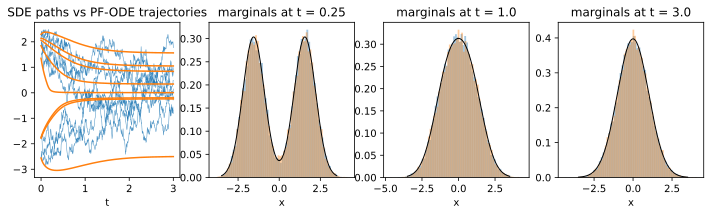

In [6]:
def pf_velocity(x, t):                  # v = f - (1/2) g^2 score
    return -theta * x - 0.5 * sigma**2 * score_t(x, t)

def ks_distance(a, b):                  # max gap between empirical CDFs
    zs = np.sort(np.concatenate([a, b]))
    Fa = np.searchsorted(np.sort(a), zs, side='right') / len(a)
    Fb = np.searchsorted(np.sort(b), zs, side='right') / len(b)
    return np.abs(Fa - Fb).max()

rng = np.random.default_rng(0)
n, T, steps = 20_000, 3.0, 600
dt = T / steps
x_sde = sample_p0(n, rng); x_ode = x_sde.copy()
ts_show, snaps_sde, snaps_ode = (0.25, 1.0, 3.0), {}, {}
paths_sde, paths_ode = [x_sde[:8].copy()], [x_ode[:8].copy()]
for k in range(steps):
    t = k * dt
    x_sde += -theta * x_sde * dt + sigma * np.sqrt(dt) * rng.standard_normal(n)
    k1 = pf_velocity(x_ode, t)          # Heun (improved Euler) for the ODE
    k2 = pf_velocity(x_ode + dt * k1, t + dt)
    x_ode += 0.5 * dt * (k1 + k2)
    paths_sde.append(x_sde[:8].copy()); paths_ode.append(x_ode[:8].copy())
    for s in ts_show:
        if abs((k + 1) * dt - s) < 1e-9:
            snaps_sde[s] = x_sde.copy(); snaps_ode[s] = x_ode.copy()

fig, axes = d2l.plt.subplots(1, 4, figsize=(12, 2.8))
tt = np.linspace(0, T, steps + 1)
for path in np.array(paths_sde).T:
    axes[0].plot(tt, path, lw=0.5, color='C0', alpha=0.8)
for path in np.array(paths_ode).T:
    axes[0].plot(tt, path, lw=1.5, color='C1')
axes[0].set_xlabel('t'); axes[0].set_title('SDE paths vs PF-ODE trajectories')
gx = np.linspace(-3.5, 3.5, 400)
for ax, s in zip(axes[1:], ts_show):
    ax.hist(snaps_sde[s], bins=70, density=True, alpha=0.4, color='C0')
    ax.hist(snaps_ode[s], bins=70, density=True, alpha=0.4, color='C1')
    ax.plot(gx, p_t(gx, s), 'k', lw=1)
    ax.set_xlabel('x'); ax.set_title(f'marginals at t = {s}')
    print(f't={s}: KS(SDE cloud, ODE cloud) = '
          f'{ks_distance(snaps_sde[s], snaps_ode[s]):.4f}')

The leftmost panel is the whole story in one image: thin blue SDE paths
rattle, jitter, and cross; thick orange ODE trajectories glide smoothly and
never touch. Yet in every histogram panel the two clouds are statistically
identical: the Kolmogorov--Smirnov distance between the two
$20{,}000$-particle clouds stays in the $0.006$--$0.009$ range, below the
$\approx 0.014$ critical value (at significance level $\alpha = 0.05$) for
two independent samples of the *same* distribution at this size, and both
sit on the analytic $p_t$ (black curve). Same marginals, different
choreography: the probability-flow ODE is a working deterministic sampler,
four lines of NumPy plus one ingredient we took from a closed form, the
score.

## The Score Function

### The One Unknown

The quantity

$$
\mathbf{s}_t(\mathbf{x}) = \nabla_{\mathbf{x}} \log p_t(\mathbf{x})
$$

is called the **score** of the density $p_t$ (in this context sometimes the
*Stein score*). The gradient is with respect to the *input*
$\mathbf{x}$, not with respect to any parameters; this differs from the
statistician's score of that section, which is the
canonical home of the definition and of the Fisher divergence built from it.
Geometrically, $\mathbf{s}_t$ is a vector field over data space: at each point
it points in the direction of steepest ascent of the log-density ("uphill,
toward the data"), with length proportional to how fast the density rises.
It vanishes exactly at the critical points of $p_t$: at modes (where everything
around is downhill) and at troughs and saddles between them.
the figure shows the field for a two-mode density in
two dimensions.

![The score $\mathbf{s}(\mathbf{x})=\nabla\log p(\mathbf{x})$ of a two-component Gaussian mixture, drawn as a vector field over the density contours. The arrows point uphill on the density, toward the nearest mode, and vanish at the two modes (orange) where the density is locally flat. This vector field is the only quantity in the probability-flow ODE and the reverse SDE that is not known by design.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-score-field.svg)

### Two Worked Scores

**The Gaussian.** For
$p(\mathbf{x}) = \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \sigma^2 I)$ the
log-density is
$-\|\mathbf{x} - \boldsymbol{\mu}\|^2 / (2\sigma^2) + \textrm{const}$, so

$$
\nabla \log p(\mathbf{x}) = -\frac{\mathbf{x} - \boldsymbol{\mu}}{\sigma^2} :
$$

a linear spring pulling toward the mean, stiffer for smaller $\sigma$. (For a
general covariance, $-\Sigma^{-1}(\mathbf{x} - \boldsymbol{\mu})$.) This is
the analytic score we used to validate the probability-flow ODE, and it is the
reason everything in this chapter can be checked without learning anything.

**The mixture.** For $p(x) = \sum_k \pi_k\, \mathcal{N}(x; \mu_k, s_k^2)$,
differentiate $\log p = \log \sum_k \pi_k N_k$ directly:

$$
\nabla \log p(x) = \frac{\sum_k \pi_k \nabla N_k}{\sum_j \pi_j N_j} = \sum_k \gamma_k(x) \left(-\frac{x - \mu_k}{s_k^2}\right), \qquad \gamma_k(x) = \frac{\pi_k N_k(x)}{\sum_j \pi_j N_j(x)}.
$$

The mixture's score is the *responsibility-weighted average of the component
scores*: each point listens to all the springs, weighted by the posterior
probability $\gamma_k(x)$ that it belongs to component $k$. (This
posterior-average structure is no accident: it returns as the central
identity behind denoising score matching in
that section.) For the symmetric
two-component case $\pi_{1,2} = \tfrac12$, $\mu_{1,2} = \pm\mu$, equal
$s_0^2$, the responsibilities collapse to a logistic and the score has a
closed form:

$$
s(x) = \frac{\mu \tanh\!\left(\mu x / s_0^2\right) - x}{s_0^2}.
$$

Near each mode, $\tanh \to \pm 1$ and $s(x) \approx -(x \mp \mu)/s_0^2$,
the local Gaussian spring. At $x = 0$ the score vanishes (the trough between
the modes is a critical point too), but it is a *repeller*: infinitesimally to
the right of $0$ the score is large and positive, pushing mass toward $+\mu$.

### Why Scores Beat Densities

Suppose you only know the density up to its normalizing constant:
$p(\mathbf{x}) = \tilde{p}(\mathbf{x}) / Z$ with
$Z = \int \tilde{p}\, d\mathbf{x}$ unknown, the standing situation for
energy-based models $p \propto e^{-E(\mathbf{x})}$
[@LeCun.Chopra.Hadsell.ea.2006], where $Z$ is an integral
over all of $\mathbb{R}^d$ that nobody can compute. The score does not care:
since $Z$ is constant in $\mathbf{x}$,
$\nabla \log p = \nabla \log \tilde{p}$, the normalizer-blindness of the
score the equation established in
that section. For the energy-based model the score
is simply $-\nabla E$. *This* is why the score is the right object to learn:
a neural network can represent a vector field without ever promising that it
integrates to one, and the Fisher divergence of
that section measures the quality of such a field
directly. The probability-flow ODE and (next) the reverse SDE consume only
the score, so the entire generative problem reduces to score estimation,
which is that section's job.

The code makes all three points at once: it plots the bimodal score field
the equation, confirms the responsibility formula against
it, locates the zeros, and checks that scaling the density by an arbitrary
constant changes the score by *nothing*.

max|responsibility - tanh form| = 5.15e-14
score vanishes near: [-2.  0.  2.]
max|score(7.3 p) - score(p)| = 3.55e-13


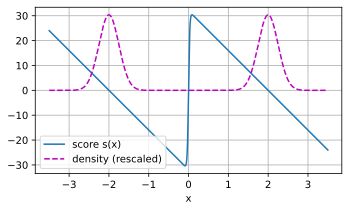

In [7]:
gs = np.linspace(-3.5, 3.5, 1401)
dg = gs[1] - gs[0]
s_resp = score_t(gs, 0.0)                       # responsibility formula
s_tanh = (2.0 * np.tanh(2.0 * gs / 0.0625) - gs) / 0.0625   # closed form
print(f'max|responsibility - tanh form| = {np.abs(s_resp - s_tanh).max():.2e}')

zeros = gs[:-1][np.sign(s_resp[:-1]) != np.sign(s_resp[1:])]
print(f'score vanishes near: {np.unique(np.round(zeros, 2) + 0.0)}')

s_unnorm = np.gradient(np.log(7.3 * p_t(gs, 0.0)), dg)      # density scaled by 7.3
s_norm = np.gradient(np.log(p_t(gs, 0.0)), dg)
print(f'max|score(7.3 p) - score(p)| = {np.abs(s_unnorm - s_norm).max():.2e}')

dens = p_t(gs, 0.0)
d2l.plot(gs, [s_resp, dens * (np.abs(s_resp).max() / dens.max())], 'x', '',
         legend=['score s(x)', 'density (rescaled)'], figsize=(5.5, 3))

The two formulas agree to machine precision; the zeros sit at the modes
$\pm 2$ and the repelling trough at $0$; and multiplying the density by $7.3$
moves the (finite-difference) score by less than $10^{-12}$: the
normalizer is invisible. Note the shape of the plot: the score is *largest in the empty
region between the modes*, where the log-density climbs steeply toward the
nearest mode, precisely where a generative sampler, arriving from noise,
most needs directions.

## Time Reversal

### Bayes on an Infinitesimal Step

The forward SDE destroys data into noise. Generation needs the process played
backward, and the backward process is *again* a
diffusion, with a drift we can write down. The intuition is one application of
Bayes' rule, on a single infinitesimal step.

Over a short interval $\tau$, the forward kernel is the Euler--Maruyama
Gaussian (that section):

$$
p(\mathbf{x}_{t+\tau} \mid \mathbf{x}_t) \approx \mathcal{N}\big(\mathbf{x}_{t+\tau};\; \mathbf{x}_t + \mathbf{f}(\mathbf{x}_t, t)\,\tau,\; g^2 \tau I\big).
$$

Reversing a step means asking: given where the particle *landed*,
$\mathbf{x}_{t+\tau} = \mathbf{y}$, where did it *come from*? Bayes' rule
answers with the forward kernel reweighted by the marginal:

$$
p(\mathbf{x}_t = \mathbf{x} \mid \mathbf{x}_{t+\tau} = \mathbf{y}) \propto p(\mathbf{y} \mid \mathbf{x})\; p_t(\mathbf{x}).
$$

Take logs and expand $\log p_t(\mathbf{x})$ around the landing point:
$\log p_t(\mathbf{x}) \approx \log p_t(\mathbf{y}) + (\mathbf{x} - \mathbf{y}) \cdot \nabla \log p_t(\mathbf{y})$,
with corrections of higher order in $\tau$ (the step is of size
$\sqrt{\tau}$). Adding this linear term to the Gaussian exponent
$-\|\mathbf{x} - (\mathbf{y} - \mathbf{f}\tau)\|^2 / (2 g^2 \tau)$ and
completing the square shifts the mean by $g^2 \tau\, \nabla \log p_t(\mathbf{y})$:

$$
p(\mathbf{x} \mid \mathbf{y}) \approx \mathcal{N}\big(\mathbf{x};\; \mathbf{y} - [\mathbf{f}(\mathbf{y}, t) - g^2 \nabla \log p_t(\mathbf{y})]\,\tau,\; g^2 \tau I\big).
$$

Stepping *backward* is therefore again a Gaussian kick of variance
$g^2 \tau$ (a diffusion) whose drift is the forward drift *corrected by
the full $g^2$ times the score*. The marginal $p_t$ acts as a Bayesian prior
that bends the reversed step toward where the data density actually was. (One
bookkeeping remark for the careful reader: we evaluated $\mathbf{f}$ and the
score at the landing point $\mathbf{y}$ rather than at $\mathbf{x}$; since the
step itself is of size $\sqrt{\tau}$, switching evaluation points perturbs the
mean only at order $\tau^{3/2}$, invisible at the order $\tau$ we keep.)

### Anderson's Theorem

The infinitesimal picture is a theorem [@Anderson.1982]: the
time-reversal of the diffusion
$d\mathbf{X} = \mathbf{f}\,dt + g\,d\mathbf{W}$ is the **reverse-time SDE**

$$
d\mathbf{X} = \big[\mathbf{f}(\mathbf{X}, t) - g(t)^2\, \nabla_{\mathbf{x}} \log p_t(\mathbf{X})\big]\,dt + g(t)\, d\bar{\mathbf{W}},
$$

integrated from $t = T$ down to $t = 0$, where $\bar{\mathbf{W}}$ is a
Brownian motion running in reverse time. Started from
$\mathbf{X}_T \sim p_T$, its marginals are $p_t$ at every intermediate time:
noise flows back into data.

Compare the drift corrections: the reverse SDE uses $-g^2 \nabla \log p_t$,
the probability-flow ODE used $-\tfrac12 g^2 \nabla \log p_t$. The factor of
two is real. To see why, and to prove Anderson's theorem at the marginal
level, use Fokker--Planck bookkeeping with a noise dial.

**Proposition (one family, marginals fixed).** *Let $p_t$ solve the
Fokker--Planck equation. For any $\lambda \ge 0$, the reverse-time SDE with
noise scale $\lambda g$ and drift*

$$
\mathbf{b}_\lambda = \mathbf{f} - \tfrac{1 + \lambda^2}{2}\, g^2\, \nabla \log p_t
$$

*has marginals $p_t$ when started from $p_T$. The choice $\lambda = 1$ is
Anderson's reverse SDE the equation; the choice
$\lambda = 0$ is the probability-flow ODE the equation.*

**Proof.** Run the clock backward: let $s = T - t$ and
$q_s = p_{T-s}$, the density evolution played in reverse, so
$\partial_s q_s = -\partial_t p_t = \nabla \cdot (\mathbf{f} p) - \tfrac12 g^2 \Delta p$.
A reverse-time SDE $d\mathbf{Y} = \mathbf{b}'\,ds + \lambda g\, d\mathbf{W}$
has its own Fokker--Planck equation
$\partial_s q = -\nabla \cdot (q\, \mathbf{b}') + \tfrac{\lambda^2}{2} g^2 \Delta q$.
Matching the two right-hand sides and converting *both* Laplacians to
transport form with the equation:

$$
-\nabla \cdot (q\, \mathbf{b}') = \nabla \cdot (\mathbf{f} q) - \tfrac{1 + \lambda^2}{2} g^2 \Delta q = \nabla \cdot \Big(q \Big[\mathbf{f} - \tfrac{1 + \lambda^2}{2} g^2 \nabla \log q\Big]\Big),
$$

which holds with
$\mathbf{b}' = -\mathbf{f} + \tfrac{1+\lambda^2}{2} g^2 \nabla \log q$, the
natural gradient-form choice. (Drifts with the same marginals can differ by a
field that is divergence-free after multiplication by $q$; in dimension
$d = 1$, and only there, decay at infinity forces that field to vanish, so
the choice is unique.) Translating $\mathbf{b}'$ back to forward-time
notation flips its sign and gives the equation. It
remains to pass from equal evolution equations plus the equal start
$q_0 = p_T$ to equal marginals: for $\lambda = 0$ this is the
transport-equation uniqueness used for the deterministic twin above, and for
$\lambda > 0$ it is uniqueness for a *parabolic* Fokker--Planck equation,
which we take as a granted fact under our standing assumptions
[@Risken.1996]. $\blacksquare$

The factor of two now has an explanation. The reverse process *keeps
injecting noise*, and its own diffusion smooths the density just as the
forward one did. So the reverse drift must work twice: one
$-\tfrac12 g^2 \nabla \log p_t$
merely switches off the forward smoothing (that alone is the
probability-flow ODE, which injects no noise), and a second
$-\tfrac12 g^2 \nabla \log p_t$ pre-compensates the smoothing that the
reverse-time noise will re-inflict. Anderson's $\lambda = 1$ pays both
charges; the dial in between trades off sampler stochasticity at fixed
marginals, a freedom that diffusion-model samplers exploit deliberately
(that section).
the figure shows the dial in action: three values of
$\lambda$, three path textures, one terminal histogram. Rigorously,
Anderson's result is a statement about the full reverse-time *process*
(filtrations, reverse Brownian motions and all), stronger than the marginal
statement proved here; see @Anderson.1982 .

![One dial, one density movie. Left: reverse-time trajectories from the same terminal noise draws, integrated with the exact mixture score under the drift $\mathbf{f} - \tfrac{1+\lambda^2}{2} g^2 \nabla \log p_t$ and noise $\lambda g$: the probability-flow ODE $\lambda = 0$ glides, $\lambda = 0.5$ rattles gently, Anderson's reverse SDE $\lambda = 1$ is jagged. More injected noise demands more drift correction, the factor sliding from $\tfrac12 g^2$ up to $g^2$ so the extra smoothing is pre-compensated. Right: after the full reverse pass, all three clouds land in the same terminal histogram, the bimodal data density $p_0$. Marginals fixed, paths free.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-lambda-family.svg)

Note what the equation asks of us. The forward drift
$\mathbf{f}$ and schedule $g$: chosen by us. The terminal distribution
$p_T$: by design, approximately a known Gaussian (the whole point of noising).
The score $\nabla \log p_t$: the *single* unknown, the same one the
probability-flow ODE needed. One function to learn, two samplers for free.
the figure shows the pair of processes as evolving
densities, the one-dimensional rendition of the two-dimensional cloud story
that the figure tells in the next section.

![The forward and reverse diffusion processes on a density. Top row (left to right): the forward noising SDE turns a structured bimodal data density $p_0$ into a single Gaussian $p_T$ across a few time slices, each panel an exact variance-preserving (OU) marginal of the mixture. Bottom row (right to left): the reverse process, driven by the score $\nabla\log p_t$, runs the same marginals backward to recover the data density from noise. Forward is fixed by design; reverse needs only the learned score.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-dyn-forward-reverse.svg)

### Noise Back into Data

The final demonstration is generation itself, with the learned network
replaced by our closed-form mixture score: diffusion sampling with zero
training. We draw $20{,}000$ points from $\mathcal{N}(0, 1)$ (which
approximates $p_T$ at $T = 3$; the code measures how well) and integrate
Anderson's reverse SDE down to $t = 0$ in the reversed clock $s = T - t$,
where the equation reads
$d\mathbf{Y} = [-\mathbf{f} + g^2 \nabla \log p_t]\,ds + g\,d\mathbf{W}$.

max|p_T - N(0,1)| at T=3: 0.0015  (vs peak 0.3974)


mass split: 0.500 / 0.500  (target 0.5 / 0.5)
left mode:  mean -1.999, std 0.260  (target -2.000, 0.250)
right mode: mean +2.001, std 0.261  (target +2.000, 0.250)
KS(generated, exact p0 sample) = 0.0172


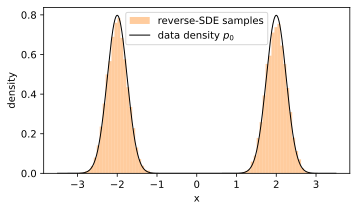

In [8]:
gap = np.abs(p_t(gs, 3.0) - gauss(gs, 0.0, 1.0)).max()
print(f'max|p_T - N(0,1)| at T=3: {gap:.4f}  (vs peak {p_t(gs, 3.0).max():.4f})')

rng = np.random.default_rng(7)
n, T, steps = 20_000, 3.0, 600
dt = T / steps
x = rng.standard_normal(n)              # start from N(0,1), our stand-in for p_T
for k in range(steps):
    t = T - k * dt                      # current forward time, running down
    drift_rev = theta * x + sigma**2 * score_t(x, t)   # -f + g^2 * score
    x += drift_rev * dt + sigma * np.sqrt(dt) * rng.standard_normal(n)

left, right = x[x < 0], x[x >= 0]
print(f'mass split: {len(left)/n:.3f} / {len(right)/n:.3f}  (target 0.5 / 0.5)')
print(f'left mode:  mean {left.mean():+.3f}, std {left.std():.3f}  '
      f'(target -2.000, 0.250)')
print(f'right mode: mean {right.mean():+.3f}, std {right.std():.3f}  '
      f'(target +2.000, 0.250)')
print(f'KS(generated, exact p0 sample) = '
      f'{ks_distance(x, sample_p0(n, np.random.default_rng(99))):.4f}')

d2l.set_figsize((5.5, 3))
d2l.plt.hist(x, bins=80, density=True, alpha=0.4, color='C1',
             label='reverse-SDE samples')
d2l.plt.plot(gs, p_t(gs, 0.0), 'k', lw=1, label='data density $p_0$')
d2l.plt.xlabel('x'); d2l.plt.ylabel('density'); d2l.plt.legend();

Starting from featureless Gaussian noise (justified, since
$\max_x |p_T - \mathcal{N}(0,1)|$ is about $0.0015$ against a density peak of
$0.40$), the reverse SDE re-grows both modes at $\pm 2.00$ and splits its
mass $0.500/0.500$. The recovered mode widths read $0.260$ and $0.261$
against the target $0.250$: that is Euler--Maruyama's $O(\Delta t)$ weak bias
(that section), and halving the step size moves them
toward $0.25$, to $0.255$ and $0.252$ (try it). The same bias is what nudges
the Kolmogorov--Smirnov distance to a fresh exact $p_0$ sample ($0.017$)
slightly above the two-sample sampling floor. Every diffusion model you have
seen generating images is this loop, with two substitutions: $\mathbf{x}$
lives in a million dimensions, and $\nabla \log p_t$, the one thing we got
for free from a Gaussian mixture, is a trained neural network. How to train
it is the business of that section.

## Summary

* A single SDE path is random, but the ensemble's time-marginal
  $p_t(\mathbf{x})$ evolves deterministically. Its law of motion is the
  **Fokker--Planck equation**. For diffusion matrix $a=GG^\top$, it is
  $\partial_t p=-\sum_i\partial_i(f_i p)
  +\tfrac12\sum_{ij}\partial_i\partial_j(a_{ij}p)$; the familiar scalar
  form uses $a=g(t)^2I$. The probability current makes boundary assumptions
  explicit: reflecting boundaries have zero normal flux, periodic boundaries
  match flux, and absorbing boundaries can lose mass.
* Three self-contained vector-calculus facts power everything: the divergence
  as flux per unit volume (with the divergence theorem), the Laplacian as
  deviation from the neighborhood average, and integration by parts
  $\int h\, \nabla \cdot \mathbf{v} = -\int \nabla h \cdot \mathbf{v}$ for
  decaying fields.
* A Gaussian $\mathcal{N}(m(t), v(t))$ solves the OU Fokker--Planck equation
  iff $\dot m = -\theta m$ and $\dot v = \sigma^2 - 2\theta v$, so the OU
  transition density solves it, and the stationary
  $\mathcal{N}(0, \sigma^2/2\theta)$ is its steady state.
* Deterministic flows obey the **continuity equation**
  $\partial_t p + \nabla \cdot (p \mathbf{v}) = 0$. Via
  $\nabla p = p \nabla \log p$, the diffusion term is transport in disguise:
  $\tfrac12 g^2 \Delta p = \nabla \cdot (p \cdot \tfrac12 g^2 \nabla \log p)$,
  with a *plus* sign. So Fokker--Planck is a continuity equation with
  velocity $\mathbf{v}_t = \mathbf{f} - \tfrac12 g^2 \nabla \log p_t$.
* The **probability-flow ODE** $\dot{\mathbf{x}} = \mathbf{v}_t(\mathbf{x})$
  shares every time-marginal with the SDE under the stated smoothness,
  positivity, boundary, and well-posedness assumptions. Its trajectories are
  deterministic and, where the flow exists uniquely in both directions,
  invertible. CNF likelihood evaluation is exact only with the exact field,
  divergence, and numerical integration.
* The **score** $\nabla_{\mathbf{x}} \log p_t$ is a vector field pointing
  uphill on the log-density; it ignores the normalizing constant, which is
  why it is learnable where the density is not. Gaussian:
  $-(\mathbf{x} - \boldsymbol{\mu})/\sigma^2$; mixtures:
  responsibility-weighted component scores.
* **Anderson's theorem**: the time reversal of a diffusion is the diffusion
  $d\mathbf{X} = [\mathbf{f} - g^2 \nabla \log p_t]\,dt + g\,d\bar{\mathbf{W}}$.
  The reverse SDE's correction is $g^2$ (it must undo forward smoothing *and*
  pre-compensate its own noise); the PF-ODE's is $\tfrac12 g^2$; a whole
  $\lambda$-family interpolates at fixed marginals. The score is the only
  unknown in all of them.

Everything a diffusion model does at inference time (its samplers and its
likelihoods, the subject of that section)
runs on this section's three objects: the probability-flow ODE, the reverse
SDE, and the likelihood integral the equation. The lone
unknown in all three is the score.

## Exercises

1. **Stationary distribution from scratch.** Set $\partial_t p = 0$ in the OU
   Fokker--Planck equation:
   $0 = \theta\,\partial_x(x p) + \tfrac12 \sigma^2 \partial_{xx} p$.
   Integrate once in $x$ and argue from decay at infinity that the constant of
   integration (the probability current) must vanish. Solve the resulting
   first-order ODE and confirm $p_\infty = \mathcal{N}(0, \sigma^2/2\theta)$;
   no Gaussian ansatz allowed.
2. **Heat kernel.** Use the moment-ODE proposition with $\theta = 0$ to show
   that $\mathcal{N}(x_0, v_0 + \sigma^2 t)$ solves the heat equation
   the equation, and conclude the marginal law of
   Brownian motion started from $x_0$. What happens as $v_0 \to 0$?
3. **Continuity from conservation.** Re-derive the continuity equation
   the equation from the divergence theorem without looking,
   then derive the along-trajectory rule
   $\frac{d}{dt} \log q_t(\mathbf{x}(t)) = -\nabla \cdot \mathbf{v}$ and
   reconcile it with the instantaneous change-of-variables formula of
   that section.
4. **The sign, in $d$ dimensions.** Prove
   $\tfrac12 \nabla \cdot (g^2 \nabla p) = \nabla \cdot (p \cdot \tfrac12 g^2 \nabla \log p)$
   for $\mathbf{x} \in \mathbb{R}^d$ and time-dependent scalar $g$, stating
   exactly where you use $p > 0$. Then explain, in one sentence each, why the
   right-hand side carries a plus sign while the probability-flow velocity
   carries $-\tfrac12 g^2 \nabla \log p$.
5. **The Gaussian flow is affine.** For OU started from the point mass
   $\delta_{x_0}$, the marginal is the Gaussian
   the equation. Show that the probability-flow velocity
   $v_t(x) = -\theta x - \tfrac12 \sigma^2 \cdot \big(-(x - m_t)/v_t\big)$ is
   affine in $x$, solve the PF-ODE in closed form, and verify that it maps
   $\mathcal{N}(m_s, v_s)$ to $\mathcal{N}(m_t, v_t)$. Why can two of its
   trajectories never cross, while two SDE paths can?
6. **The factor of two.** Re-derive the family
   the equation from Fokker--Planck bookkeeping. Explain
   in words why the reverse SDE needs $g^2 \nabla \log p_t$ where the PF-ODE
   needs only $\tfrac12 g^2 \nabla \log p_t$, and what the dial $\lambda$
   trades off.
7. **Mixture scores.** Derive the responsibility formula
   the equation for $K$ components, then specialize to
   the symmetric two-component case to obtain
   the equation. Find all zeros of
   the equation when $\mu \gg s_0$ and classify each as a
   mode or a repeller of the ascent flow $\dot x = s(x)$.
8. **Break the sampler.** Rerun the reverse-SDE experiment with two
   modifications, one at a time: (a) an asymmetric prior
   $\pi = (0.25, 0.75)$ (predict the recovered mass split before you run);
   (b) the *wrong* drift correction $\tfrac12 g^2 \nabla \log p_t$ while
   keeping the noise: describe what the recovered density looks like and
   explain why, using the $\lambda$-family with mismatched drift and noise.